In [4]:
from unittest.mock import patch

import numpy as np
import pandas as pd

import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

import json

from astropy.extern.configobj.validate import is_list
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

from scipy.optimize import minimize

from tqdm.auto import tqdm

from skimage.color import xyz2rgb

import torch
from torch.utils.data import Dataset, DataLoader
import random
from tqdm import tqdm

import torch.nn as nn
from torch import Tensor

from models import HSCNNp

In [5]:
munsell = pd.read_csv("data/munsell.csv")
munsell.set_index('wavelength', inplace=True)
# Нет смысла в интерполяции тк мы берём точки, которые есть в датасете
munsell = munsell.loc[range(400, 710, 10)]
munsell.head()

,0,1,2,3,4,5,6,7,8,9,...,1259,1260,1261,1262,1263,1264,1265,1266,1267,1268
wavelength,,,,,,,,,,,,,,,,,,,,,
400.0,0.42400,0.3967,0.33770,0.26110,0.18220,0.11590,0.06860,0.05210,0.3889,0.33320,...,0.0628,0.30970,0.24330,0.16570,0.1051,0.2284,0.16310,0.11590,0.1708,0.10470
410.0,0.63445,0.5154,0.38970,0.27695,0.18600,0.11465,0.06905,0.04775,0.4986,0.37795,...,0.0613,0.35155,0.25745,0.16445,0.1048,0.2442,0.16135,0.11100,0.1666,0.10215
420.0,0.69580,0.5326,0.38770,0.27000,0.17960,0.11140,0.06600,0.04620,0.5074,0.37420,...,0.0614,0.34380,0.24560,0.15800,0.1001,0.2337,0.15610,0.10410,0.1590,0.09910
430.0,0.69880,0.5229,0.38045,0.26185,0.17405,0.10775,0.06470,0.04695,0.4944,0.36195,...,0.0592,0.33440,0.23545,0.15390,0.0981,0.2251,0.15000,0.10095,0.1545,0.09700
440.0,0.69800,0.5212,0.37520,0.26000,0.17200,0.11080,0.06290,0.04960,0.4879,0.35430,...,0.0579,0.32730,0.23010,0.15240,0.0977,0.2205,0.14800,0.09450,0.1548,0.09600


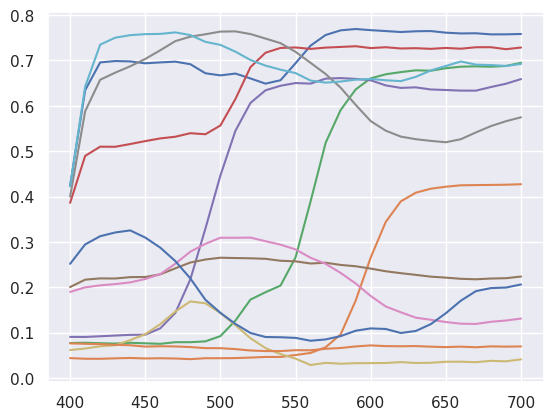

In [6]:
sns.set_theme("notebook")
for i in range(0, 1200, 100):
    plt.plot(munsell.index, munsell[str(i)])
plt.show()

In [7]:
illium = pd.read_csv("data/illum.csv")
illium.head()

,wavelength,A18,A24,A28,D50,D55,D65,D75,D95,F1,...,L-9,L-10,L-11,L-12,L-13,L-14,L-15,L-LIFX-R,L-LIFX-G,L-LIFX-B
0,300,7.644910e-07,0.000019,0.000086,0.000015,0.000014,0.000021,0.000027,9.401700e-19,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,301,8.214660e-07,0.000020,0.000090,0.000023,0.000033,0.000033,0.000035,4.706710e-05,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,302,8.822190e-07,0.000021,0.000093,0.000032,0.000053,0.000047,0.000045,9.149980e-05,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,303,9.469680e-07,0.000022,0.000097,0.000045,0.000074,0.000065,0.000060,1.298860e-04,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,304,1.015940e-06,0.000023,0.000101,0.000062,0.000095,0.000088,0.000081,1.622290e-04,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
# TODO interpolate
illium.set_index('wavelength', inplace=True)
illium = illium.loc[400:700:10]

In [9]:
illium = illium / illium.sum(axis=0)

In [10]:
sensor = pd.read_csv('data/xyz_matching_fun.csv')
sensor.set_index('wavelength', inplace=True)
sensor = sensor.loc[range(400, 710, 10)]
sensor

,X,Y,Z
wavelength,,,
400.0,0.02,0.00,0.09
410.0,0.08,0.01,0.39
420.0,0.20,0.02,0.97
430.0,0.31,0.04,1.55
440.0,0.38,0.06,1.97
450.0,0.37,0.09,1.99
460.0,0.30,0.13,1.75
470.0,0.20,0.19,1.32
480.0,0.08,0.25,0.77


In [11]:
munsell.T

wavelength,400.0,410.0,420.0,430.0,440.0,450.0,460.0,470.0,480.0,490.0,...,610.0,620.0,630.0,640.0,650.0,660.0,670.0,680.0,690.0,700.0
0,0.4240,0.63445,0.6958,0.69880,0.6980,0.69380,0.6958,0.69745,0.6918,0.67185,...,0.76490,0.7628,0.76445,0.7649,0.76135,0.7597,0.76005,0.7576,0.75770,0.7585
1,0.3967,0.51540,0.5326,0.52290,0.5212,0.51140,0.5085,0.51310,0.5060,0.49175,...,0.57710,0.5763,0.57380,0.5706,0.56545,0.5659,0.56685,0.5662,0.56330,0.5610
2,0.3377,0.38970,0.3877,0.38045,0.3752,0.37150,0.3715,0.37045,0.3642,0.34995,...,0.43195,0.4295,0.42850,0.4238,0.42375,0.4254,0.42185,0.4213,0.41550,0.4157
3,0.2611,0.27695,0.2700,0.26185,0.2600,0.25485,0.2507,0.25310,0.2477,0.23615,...,0.30545,0.3021,0.29730,0.2966,0.29645,0.2955,0.29325,0.2913,0.28595,0.2878
4,0.1822,0.18600,0.1796,0.17405,0.1720,0.16405,0.1622,0.16590,0.1629,0.15475,...,0.20625,0.2058,0.20250,0.1992,0.19625,0.1983,0.19610,0.1980,0.19160,0.1932
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1264,0.2284,0.24420,0.2337,0.22510,0.2205,0.21045,0.2090,0.21165,0.2006,0.18010,...,0.55080,0.5917,0.61485,0.6261,0.63565,0.6415,0.64155,0.6434,0.64830,0.6553
1265,0.1631,0.16135,0.1561,0.15000,0.1480,0.14455,0.1395,0.13660,0.1277,0.11605,...,0.43440,0.4831,0.50530,0.5139,0.51565,0.5177,0.51550,0.5150,0.51670,0.5144
1266,0.1159,0.11100,0.1041,0.10095,0.0945,0.08980,0.0873,0.08120,0.0745,0.06995,...,0.25550,0.3505,0.42630,0.4803,0.51565,0.5369,0.54650,0.5410,0.54525,0.5666
1267,0.1708,0.16660,0.1590,0.15450,0.1548,0.14845,0.1449,0.13900,0.1273,0.11725,...,0.50740,0.5994,0.65185,0.6801,0.69545,0.7046,0.70940,0.7137,0.71935,0.7250


In [12]:
sensor

,X,Y,Z
wavelength,,,
400.0,0.02,0.00,0.09
410.0,0.08,0.01,0.39
420.0,0.20,0.02,0.97
430.0,0.31,0.04,1.55
440.0,0.38,0.06,1.97
450.0,0.37,0.09,1.99
460.0,0.30,0.13,1.75
470.0,0.20,0.19,1.32
480.0,0.08,0.25,0.77


In [13]:
sensor.values * illium['D65'].values[:, np.newaxis]

array([[0.00056388, 0.        , 0.00253745],
       [0.00258278, 0.00032285, 0.01259105],
       [0.00651425, 0.00065142, 0.03159411],
       [0.0090204 , 0.00116392, 0.04510199],
       [0.01287349, 0.00203266, 0.06673889],
       [0.01415292, 0.0034426 , 0.07611977],
       [0.01201867, 0.00520809, 0.0701089 ],
       [0.00789664, 0.00750181, 0.05211786],
       [0.00320324, 0.01001013, 0.03083119],
       [0.00075282, 0.01279787, 0.01580914],
       [0.        , 0.01721632, 0.00823389],
       [0.00147585, 0.02250669, 0.00405858],
       [0.00418052, 0.0264766 , 0.00209026],
       [0.00860828, 0.03156368, 0.00107603],
       [0.01331585, 0.03364004, 0.00035042],
       [0.01852119, 0.03459618, 0.        ],
       [0.02413279, 0.03398985, 0.        ],
       [0.02824621, 0.03081405, 0.        ],
       [0.03221383, 0.02774855, 0.        ],
       [0.03372233, 0.02348519, 0.        ],
       [0.03399887, 0.02003505, 0.        ],
       [0.03093547, 0.01591825, 0.        ],
       [0.

In [14]:
illium['D65']

wavelength
400    0.028194
410    0.032285
420    0.032571
430    0.029098
440    0.033878
450    0.038251
460    0.040062
470    0.039483
480    0.040041
490    0.037641
500    0.037427
510    0.036896
520    0.034838
530    0.035868
540    0.035042
550    0.034946
560    0.033990
570    0.032098
580    0.031895
590    0.030109
600    0.030356
610    0.030034
620    0.029448
630    0.027979
640    0.028778
650    0.027625
660    0.027555
670    0.028043
680    0.027666
690    0.023046
700    0.024858
Name: D65, dtype: float64

In [15]:
(illium['D65'].values[:, np.newaxis]).shape

(31, 1)

In [16]:
D_65_rgb = sensor.T @ (munsell.values * illium['D65'].values[:, np.newaxis])

In [17]:
D_65_rgb

,0,1,2,3,4,5,6,7,8,9,...,1259,1260,1261,1262,1263,1264,1265,1266,1267,1268
X,0.273053,0.204543,0.151378,0.105715,0.070053,0.046320,0.027741,0.020160,0.219244,0.162969,...,0.029292,0.172125,0.125295,0.086388,0.057538,0.131155,0.093375,0.062727,0.107160,0.064922
Y,0.279148,0.207162,0.151612,0.104333,0.068421,0.043799,0.025900,0.018342,0.208695,0.153645,...,0.022507,0.143343,0.101481,0.066665,0.041663,0.100137,0.067555,0.042448,0.072805,0.041584
Z,0.289569,0.215092,0.156087,0.107038,0.070144,0.044208,0.025963,0.018924,0.201345,0.146370,...,0.022533,0.132999,0.093119,0.061159,0.038511,0.089265,0.059389,0.037445,0.060972,0.036239


In [18]:
delta_lambda = 10

In [19]:
k = 1.0 / np.sum(sensor['Y'] * illium['D65'] * delta_lambda)

In [45]:
k

np.float64(0.25495094128399076)

In [20]:
power = 1

In [21]:
response = power * k * sensor.T @ (munsell["0"] * illium['D65'].values) * 10
response
# patch = np.broadcast_to(response, (24, 24, 3))
# patch

X    0.696152
Y    0.711690
Z    0.738258
dtype: float64

In [22]:
def make_one_patch(light, power_of_light ,reflect, sensor):
    response = 10 * power_of_light * k * (sensor.T @ (reflect.values * light)).T
    patch = np.broadcast_to(response, (32, 32, 3))
    return patch

In [23]:
patch = make_one_patch(illium['D65'], 1, munsell['800'], sensor)

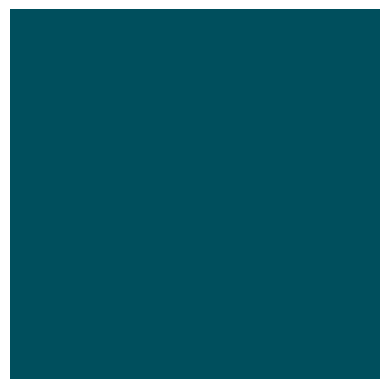

In [24]:
sns.set_theme(style="white")
from skimage.color import xyz2rgb

plt.imshow(xyz2rgb(patch))
plt.axis('off')
plt.show()

In [25]:
def make_palette(responses):
    """
    responses: (16, 3)
    """
    patches = np.tile(responses[:, np.newaxis, np.newaxis, :], (1, 32, 32, 1))
    # (16, 32, 32, 3)
    palette = patches.reshape(4, 4, 32, 32, 3)
    # (4, 4, 32, 32, 3) -> (4*32, 4*32, 3)
    palette = palette.transpose(0, 2, 1, 3, 4).reshape(128, 128, 3)

    return palette

In [26]:
def calc_responses(light, power_of_light ,reflect, sensor):
    responses = 10 * power_of_light * k * (sensor.T @ (reflect.values * light.values[:, np.newaxis])).T
    return responses

In [27]:
random_munsell = munsell.sample(n=16, axis=1)
random_munsell

,839,235,1111,79,274,388,641,667,21,88,1110,103,727,1169,686,91
wavelength,,,,,,,,,,,,,,,,
400.0,0.39200,0.03650,0.34370,0.36260,0.08370,0.20730,0.21590,0.11080,0.16100,0.07380,0.39790,0.31610,0.11880,0.07400,0.34500,0.18210
410.0,0.53110,0.03700,0.42795,0.43590,0.08220,0.22205,0.23595,0.11745,0.15995,0.07175,0.55830,0.35835,0.11770,0.07140,0.43295,0.18000
420.0,0.56700,0.03800,0.43940,0.43600,0.08070,0.22640,0.24670,0.12130,0.15310,0.06800,0.59540,0.35950,0.11780,0.07220,0.45340,0.17030
430.0,0.56425,0.03805,0.43310,0.42500,0.08025,0.23100,0.25570,0.13025,0.14640,0.06710,0.59115,0.36115,0.11825,0.06975,0.46460,0.16095
440.0,0.56560,0.03640,0.42700,0.42190,0.08090,0.24210,0.26740,0.13950,0.14440,0.06640,0.58570,0.36110,0.11850,0.06930,0.47850,0.15840
450.0,0.56085,0.03800,0.42100,0.41290,0.08200,0.25690,0.28550,0.15550,0.13880,0.06575,0.57550,0.35830,0.11925,0.06830,0.49590,0.15420
460.0,0.55950,0.03550,0.41560,0.41150,0.08150,0.28380,0.31640,0.18590,0.13950,0.06530,0.56840,0.35820,0.12030,0.06810,0.52450,0.15260
470.0,0.56010,0.03875,0.40900,0.41570,0.08150,0.32315,0.37490,0.23650,0.13845,0.06495,0.56225,0.35880,0.11945,0.06610,0.56455,0.15555
480.0,0.55630,0.03790,0.39750,0.40950,0.08090,0.37090,0.45820,0.29470,0.12860,0.06290,0.54770,0.36000,0.12300,0.06670,0.59760,0.15020


In [142]:
def apply_attenuation_light(img, x0, y0, kc=1.0, kl=0.005, kq=0.05):
    h, w, c = img.shape
    y, x = np.ogrid[:h, :w]
    d = np.sqrt((x - x0)**2 + (y - y0)**2)

    attenuation = 1.0 / (kc + kl * d + kq * (d**2))

    return img * attenuation[:, :, np.newaxis]

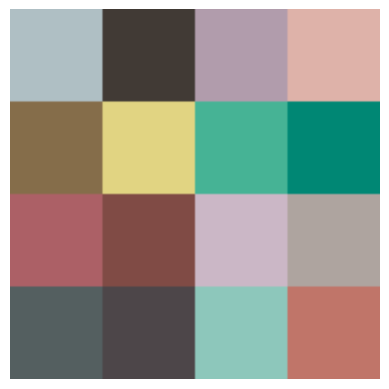

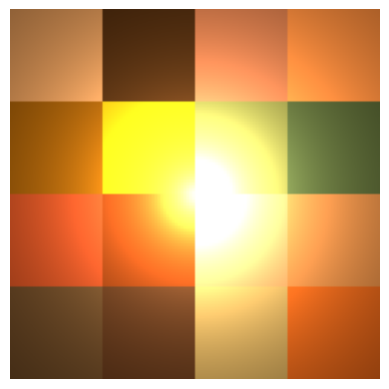

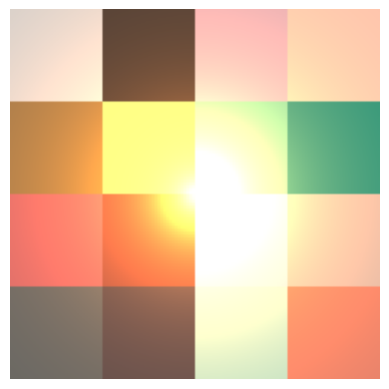

In [143]:
# https://learnopengl.com/Lighting/Light-casters
sns.set_theme(style="white")

flashlight_patch = make_palette(calc_responses(illium['L-B1'], 100, random_munsell, sensor).to_numpy())
flashlight_patch = apply_attenuation_light(flashlight_patch, 64,64)
patch = flashlight_patch + make_palette(calc_responses(illium['D65'], 1, random_munsell, sensor).to_numpy())


plt.imshow(xyz2rgb(make_palette(calc_responses(illium['D65'], 1, random_munsell, sensor).to_numpy())))
plt.axis('off')
plt.show()

plt.imshow(xyz2rgb(flashlight_patch))
plt.axis('off')
plt.show()

plt.imshow(xyz2rgb(patch))
plt.axis('off')
plt.show()

In [30]:
def make_palette_with_flashlight(light ,reflect, sensor):
    """
    мне влом(
    """
    flashlight_mask = make_palette(calc_responses(illium['L-B1'], 100, reflect, sensor).to_numpy())
    flashlight_palette = apply_attenuation_light(flashlight_mask, 64,64)
    palette = flashlight_palette + make_palette(calc_responses(light, 1, reflect, sensor).to_numpy())

    return palette

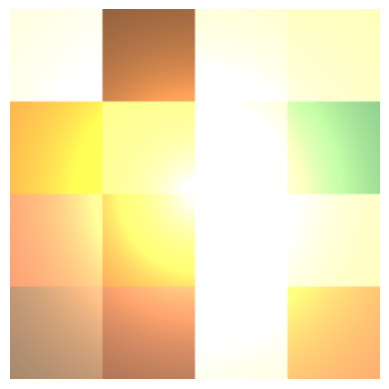

In [31]:
plt.imshow(xyz2rgb(make_palette_with_flashlight(illium['D65'], random_munsell, sensor)))
plt.axis('off')
plt.show()

In [110]:
train_val_reflect, test_reflect = train_test_split(munsell.T, test_size=112, random_state=42)
train_reflect, val_reflect = train_test_split(train_val_reflect, test_size=112, random_state=42)

In [111]:
class SpectrumDataset(Dataset):
    def __init__(self, reflect_df):
        self.reflect = torch.tensor(reflect_df.values, dtype=torch.float32)

    def __len__(self):
        return len(self.reflect)

    def __getitem__(self, idx):
        return self.reflect[idx]

In [113]:
train_dataset = SpectrumDataset(train_reflect)
val_dataset = SpectrumDataset(val_reflect)

# 512 спектров за одну итерацию
palettes_in_batch = 32
reflect_per_batch = palettes_in_batch * 16

train_loader = DataLoader(
    train_dataset,
    batch_size=reflect_per_batch,
    shuffle=True,
    drop_last=True,
    num_workers=4
)

val_loader = DataLoader(
    val_dataset,
    batch_size=7,
    shuffle=False,
    drop_last=False,
    num_workers=4
)

In [144]:
class PaletteRenderer:
    def __init__(self, sensor_df, ambient_dict, flash_series, device='cuda:0'):
        self.device = device

        # [31, 3]
        self.sensor = torch.tensor(sensor_df.values, dtype=torch.float32, device=device)

        # [31]
        self.flashlight = torch.tensor(flash_series.values, dtype=torch.float32, device=device)

        ambient_list = [ambient_dict[name].values for name in ambient_dict.keys()]
        self.ambients = torch.tensor(ambient_list, dtype=torch.float32, device=device)
        self.num_lights = self.ambients.shape[0]

        # Сетка для фонарика можем по ней определять расстояния от центра
        y, x = torch.meshgrid(torch.linspace(0, 127, 128, device=device),
                              torch.linspace(0, 127, 128, device=device), indexing='ij')
        self.y_grid = y.view(1, 128, 128, 1) # [1, 128, 128, 1]
        self.x_grid = x.view(1, 128, 128, 1) # [1, 128, 128, 1]

    def _to_palette(self, features):
        """
        [B, 16, C] -> [B, 128, 128, C]
        """
        B, num_patches, C = features.shape
        grid = features.view(B, 4, 4, C)
        # Делаем каждый патч 32*32
        grid = grid.unsqueeze(3).unsqueeze(5).expand(-1, 4, 4, 32, C, 32)
        return grid.permute(0, 1, 3, 2, 5, 4).reshape(B, 128, 128, C)
# TODO поменять k
    def render_batch(self, spectra_batch, k_exp=0.25, flash_power=100.0):
        """
        spectra_batch: тензор [B, 16, 31] (исходные спектры Манселла)
        Возвращает:
            X: [B, 6, 128, 128] (Вход модели: 3 канала со вспышкой + 3 амбиент)
            y: [B, 31, 128, 128] (Выход модели: истинный спектральный куб)
        """
        B = spectra_batch.shape[0]

        # XYZ
        light_idx = torch.randint(0, self.num_lights, (B,), device=self.device)
        batch_ambients = self.ambients[light_idx].unsqueeze(1) # [B, 1, 31]

        xyz_amb = 10 * k_exp * ((spectra_batch * batch_ambients) @ self.sensor)
        xyz_flash = 10 * k_exp * flash_power * ((spectra_batch * self.flashlight.view(1, 1, 31)) @ self.sensor)

        pal_amb = self._to_palette(xyz_amb)     # [B, 128, 128, 3]
        pal_flash = self._to_palette(xyz_flash) # [B, 128, 128, 3]

        # пока фонарик в центре, но потом можем поменять
        x0 = 64.0
        y0 = 64.0

        dist_sq = (self.x_grid - x0)**2 + (self.y_grid - y0)**2
        attenuation = 1.0 / (1.0 + 0.005 * torch.sqrt(dist_sq) + 0.05 * dist_sq)

        # merge with flashlight
        X_flash_rgb = torch.clamp(pal_amb + (pal_flash * attenuation), 0.0, 1.0)
        X_amb_rgb = torch.clamp(pal_amb, 0.0, 1.0)

        # Формат PyTorch [B, C, H, W]
        X_flash_img = X_flash_rgb.permute(0, 3, 1, 2)
        X_amb_img = X_amb_rgb.permute(0, 3, 1, 2)

        # Склеиваем по оси каналов (dim=1). Получаем 6 каналов.
        X_6chan = torch.cat([X_flash_img, X_amb_img], dim=1)

        # Спектральная картинка - y
        # Просто растягиваем исходные 31-канальные спектры в размер 128x128
        y_spectra_img = self._to_palette(spectra_batch)
        y_hsi = y_spectra_img.permute(0, 3, 1, 2)

        return X_6chan, y_hsi

In [145]:
import torch
import torch.nn as nn

def pixelwise_spectral_angle_mapper(preds: Tensor, target: Tensor, eps=1e-8):
    products = (preds * target).sum(dim=-3)
    magnitudes = preds.norm(dim=-3) * target.norm(dim=-3) + eps
    cosine_sim = torch.clamp(products / magnitudes, -1.0 + eps, 1.0 - eps)

    return torch.rad2deg(torch.acos(cosine_sim))

def pixelwise_normalized_spectral_error(preds: Tensor, target: Tensor, eps=1e-8):
    diff = (preds - target).abs().sum(dim=-3)
    scale = target.abs().sum(dim=-3) + eps
    return diff / scale

class HSILoss(nn.Module):
    def __init__(self, alpha=0.5):
        super().__init__()
        self.alpha = alpha

    def forward(self, preds, target):
        nse_loss = pixelwise_normalized_spectral_error(preds, target).mean()
        sam_loss = pixelwise_spectral_angle_mapper(preds, target).mean()

        return self.alpha * nse_loss + (1.0 - self.alpha) * sam_loss

In [146]:
device = torch.device('cuda:0')
model = HSCNNp(in_channels=6, out_channels=31, num_blocks=30).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = HSILoss(alpha=0.5).to(device)

# metric_deltaE = DeltaE().to(device)

sensor_gpu = torch.tensor(sensor.values, dtype=torch.float32, device=device)
illuminant_d65 = torch.tensor(illium['D65'].values, dtype=torch.float32, device=device)

In [147]:
selected_ambients = {
    'D65': illium['D65'],
    'D50': illium['D50'],
    'A18': illium['A18'],
    'F2': illium['F2'],
    'F11': illium['F11'],
    'L-V1': illium['L-V1'],
    'L-V2': illium['L-V2']
   # 'Flashlight': illium['L-B1']
}

renderer = PaletteRenderer(
    sensor_df=sensor,
    ambient_dict=selected_ambients,
    flash_series=illium['L-B1'],
    device='cuda:0'
)

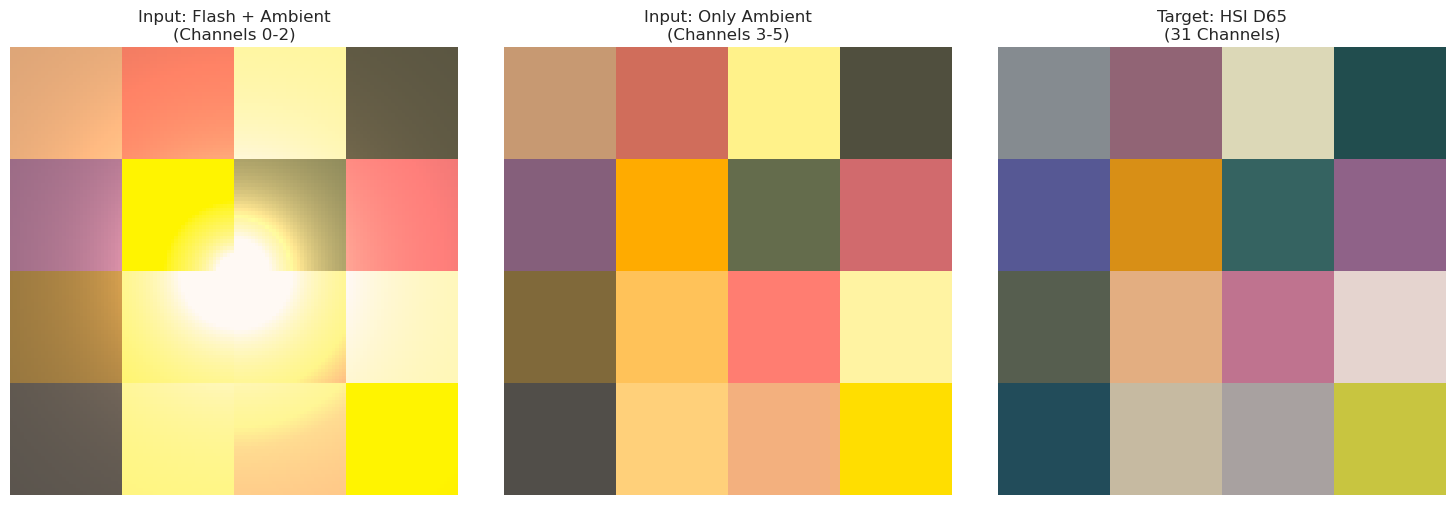

In [148]:
import matplotlib.pyplot as plt
import torch
import numpy as np

model.eval()
with torch.no_grad():
    sample_spectra = next(iter(train_loader)).to(device)

    spectra_palettes = sample_spectra.view(-1, 16, 31)

    X_batch, y_batch = renderer.render_batch(spectra_palettes)

img_6chan = X_batch[0].cpu().permute(1, 2, 0).numpy()
img_hsi = y_batch[0].cpu().permute(1, 2, 0).numpy()

img_flash = img_6chan[:, :, :3]
img_amb = img_6chan[:, :, 3:]

img_hsi_xyz = 10 * 0.25 * (img_hsi * illium['D65'].values) @ sensor.values

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(xyz2rgb(np.clip(img_flash, 0, 1)))
axes[0].set_title("Input: Flash + Ambient\n(Channels 0-2)")
axes[0].axis('off')

axes[1].imshow(xyz2rgb(np.clip(img_amb, 0, 1)))
axes[1].set_title("Input: Only Ambient\n(Channels 3-5)")
axes[1].axis('off')

axes[2].imshow(xyz2rgb(np.clip(img_hsi_xyz, 0, 1)))
axes[2].set_title("Target: HSI D65\n(31 Channels)")
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [149]:
def train_step(model, dataloader, renderer, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    pbar = tqdm(dataloader, desc="Training")

    for spectra in pbar:
        spectra = spectra.to(device)

        spectra_palettes = spectra.view(-1, 16, 31)

        X_batch, y_target = renderer.render_batch(spectra_palettes)

        optimizer.zero_grad()

        preds = model(X_batch)
        loss = criterion(preds, y_target)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        pbar.set_postfix({'Loss': f"{loss.item():.4f}"})

    return running_loss / len(dataloader)

In [126]:
def val_step(model, dataloader, criterion, device):
    model.eval()

    val_loss = 0.0
    total_sam = 0.0
    total_nse = 0.0

   # metric_deltaE.reset()

    with torch.no_grad():
        pbar = tqdm(dataloader, desc="Validation")

        for spectra in pbar:
            spectra = spectra.to(device)

            spectra_palettes = spectra.view(-1, 16, 31)

            X_batch, y_target = renderer.render_batch(spectra_palettes)

            preds = model(X_batch)

            loss = criterion(preds, y_target)
            val_loss += loss.item()

            batch_sam = pixelwise_spectral_angle_mapper(preds, y_target).mean().item()
            batch_nse = pixelwise_normalized_spectral_error(preds, y_target).mean().item()

            total_sam += batch_sam
            total_nse += batch_nse

          #  preds_rgb = xyz2rgb()
          #  target_rgb = xyz2rgb()

            # metric_deltaE.update(preds_rgb, target_rgb)

    num_batches = len(dataloader)
    metrics = {
        'Loss': val_loss / num_batches,
        'SAM_deg': total_sam / num_batches,
        'NSE': total_nse / num_batches,
       # 'DeltaE': metric_deltaE.compute().item()
    }

    return metrics

In [ ]:
EPOCHS = 100
best_sam = float('inf')

for epoch in range(EPOCHS):
    print(f"\n--- Epoch {epoch+1}/{EPOCHS} ---")

    train_loss = train_step(model, train_loader, renderer, optimizer, criterion, device)

    val_metrics = val_step(model, val_loader, criterion, device)

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss:   {val_metrics['Loss']:.4f}")
    print(f"Val SAM:    {val_metrics['SAM_deg']:.4f} (lower is better)")
    print(f"Val NSE:    {val_metrics['NSE']:.4f} (lower is better)")

    if (epoch + 1) % 20 == 0:
        checkpoint = {
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
        }

        checkpoint_path = f"checkpoints/checkpoint_epoch_{epoch+1}.pth"
        torch.save(checkpoint, checkpoint_path)
        print(f"Saved checkpoint: {checkpoint_path}")

    if val_metrics['SAM_deg'] < best_sam:
        best_sam = val_metrics['SAM_deg']
        torch.save(model.state_dict(), "best_hscnn_model.pth")
        print(f"New best model saved with SAM: {best_sam:.4f}")